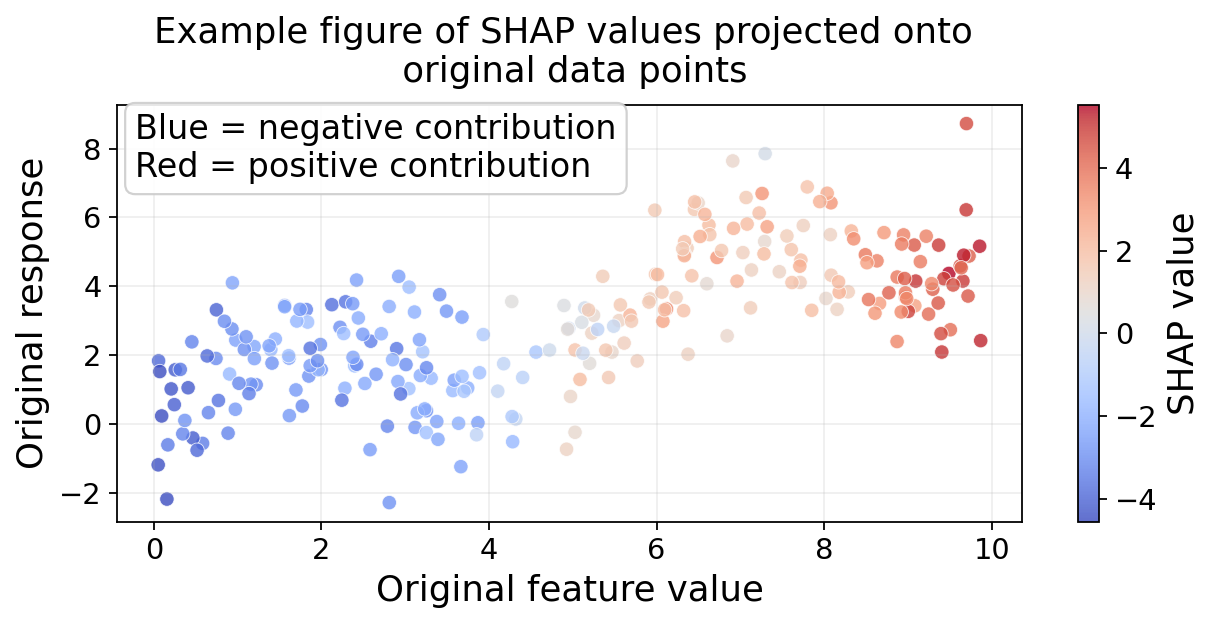

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducible synthetic example
np.random.seed(42)

# Original data points with a dispersed pattern
n = 260
x = np.random.uniform(0, 10, n)
y_base = 0.55 * x + 1.3 * np.sin(1.1 * x)
y = y_base + np.random.normal(0, 1.2, n)

# Synthetic SHAP-like values
shap = 0.9 * (x - x.mean()) + 0.8 * np.sin(1.4 * x) + np.random.normal(0, 0.6, n)

fig, ax = plt.subplots(figsize=(8, 4), dpi=160)

sc = ax.scatter(
    x, y,
    c=shap,
    cmap="coolwarm",
    s=42,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.4
)

# 标题字体变大
ax.set_title(
    "Example figure of SHAP values projected onto \n original data points",
    pad=10,
    fontsize=16
)

# 坐标轴 label 字体变大
ax.set_xlabel("Original feature value", fontsize=16)
ax.set_ylabel("Original response", fontsize=16)

# 坐标轴刻度字体也可以一起变大
ax.tick_params(axis='both', labelsize=13)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("SHAP value", fontsize=16)
cbar.ax.tick_params(labelsize=13)

ax.text(
    0.02, 0.98,
    "Blue = negative contribution\nRed = positive contribution",
    transform=ax.transAxes,
    va="top",
    fontsize=15,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9)
)

ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import pandas as pd
import shap
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# =========================
# 1. 准备数据
# =========================
data = fetch_california_housing(as_frame=True)
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 2. 训练模型
# =========================
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# =========================
# 3. 计算 SHAP 值
# =========================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# shap_values 通常是:
# 回归: (n_samples, n_features)
# 二分类/多分类: 可能是 list 或更高维数组

print("SHAP values type:", type(shap_values))
print("SHAP values shape:", np.array(shap_values).shape)

# =========================
# 4. 输出 SHAP 原始矩阵
# =========================
shap_matrix = pd.DataFrame(shap_values, columns=X_test.columns)

print("\n=== SHAP原始矩阵前5行 ===")
print(shap_matrix.head())

# 保存为 csv
shap_matrix.to_csv("shap_matrix.csv", index=False)
print("\nSHAP矩阵已保存为 shap_matrix.csv")

# =========================
# 5. 输出 base value
# =========================
base_value = explainer.expected_value
print("\nBase value:")
print(base_value)

# =========================
# 6. 验证 SHAP 加和关系
# prediction ≈ base_value + sum(shap values of one sample)
# =========================
sample_id = 0
pred = model.predict(X_test.iloc[[sample_id]])[0]
shap_sum = base_value + shap_values[sample_id].sum()

print(f"\n第{sample_id}个样本预测值: {pred:.6f}")
# print(f"base_value + SHAP和: {shap_sum:.6f}")

# =========================
# 7. 计算全局重要性向量
# mean(|SHAP|)
# =========================
global_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

print("\n=== 全局重要性向量 ===")
print(global_importance)

global_importance.to_csv("shap_global_importance.csv", header=["mean_abs_shap"])
print("\n全局重要性已保存为 shap_global_importance.csv")

# =========================
# 8. 可视化 summary plot
# =========================
shap.summary_plot(shap_values, X_test)

# =========================
# 9. 可选：计算交互值矩阵
# 仅 TreeExplainer 对树模型比较方便
# 输出形状通常是:
# (n_samples, n_features, n_features)
# =========================
try:
    shap_interaction_values = explainer.shap_interaction_values(X_test)

    print("\nInteraction values shape:", np.array(shap_interaction_values).shape)

    # 取第一个样本的交互矩阵
    interaction_matrix_sample0 = pd.DataFrame(
        shap_interaction_values[0],
        index=X_test.columns,
        columns=X_test.columns
    )

    print("\n=== 第0个样本的SHAP交互矩阵 ===")
    print(interaction_matrix_sample0)

    interaction_matrix_sample0.to_csv("shap_interaction_matrix_sample0.csv")
    print("\n第0个样本交互矩阵已保存为 shap_interaction_matrix_sample0.csv")

except Exception as e:
    print("\n当前模型或SHAP版本下无法直接计算 interaction values")
    print("错误信息:", e)

/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (4128, 8)

=== SHAP原始矩阵前5行 ===
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0 -0.846381  0.010461 -0.007353  -0.007288   -0.005462 -0.246941 -0.307581   
1 -0.715851  0.005876 -0.132610   0.048544    0.003484 -0.059921 -0.234846   
2  0.200878  0.494806  0.031372   0.065356    0.014153  1.124861  0.214810   
3  0.594896 -0.039579  0.014542  -0.004922   -0.003737 -0.328232  0.138077   
4 -0.199549  0.023316 -0.060112  -0.006174   -0.003551  0.026699  0.023938   

   Longitude  
0  -0.153814  
1  -0.243704  
2   0.695782  
3   0.083407  
4   0.387915  

SHAP矩阵已保存为 shap_matrix.csv

Base value:
[2.07306869]

第0个样本预测值: 0.508710


TypeError: unsupported format string passed to numpy.ndarray.__format__

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.8/556.8 kB 11.6 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.
